In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [6]:
df=sns.load_dataset('diamonds')
df=df[['depth','price']]
depth=df['depth'].dropna()
price=df['price'].dropna()

**• 표본평균을 구해서 저장하는 함수**  
✓ 표본의 개수=sample_size, 표본평균의 개수=num_samples(=10000)

In [7]:
def make_sampling_distribution(data, sample_size, num_samples=10000):
    sample_means=[]

    for _ in range(num_samples):
        sample=np.random.choice(data, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))

    return np.array(sample_means)

**• depth와 price 데이터의 평균과 표준편차 구하기**

In [8]:
# depth의 평균과 표준편차
depth_mean = depth.mean()
depth_std = depth.std()

# price의 평균과 표준편차
price_mean = price.mean()
price_std = price.std()

print(f"Depth - 평균: {depth_mean:.2f}, 표준편차: {depth_std:.2f}")
print(f"Price - 평균: {price_mean:.2f}, 표준편차: {price_std:.2f}")

Depth - 평균: 61.75, 표준편차: 1.43
Price - 평균: 3932.80, 표준편차: 3989.44


**• depth와 price 데이터의 분포 시각화하기(히스토그램)**  
✓ depth 데이터 분포 시각화 시 평균과 표준편차를 사용한 정규분포 그래프를 함께 시각화

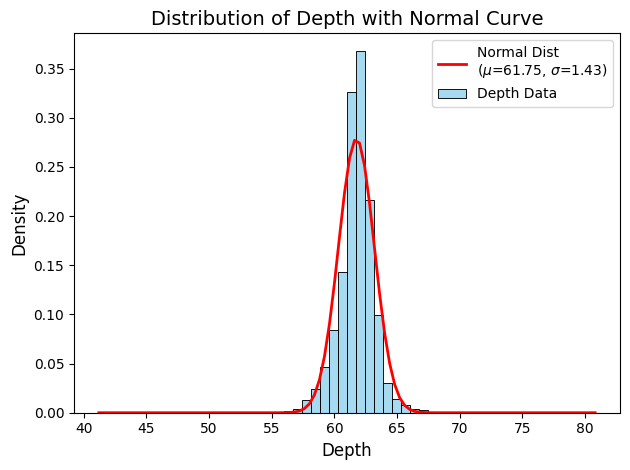

In [11]:
#depth 시각화
sns.histplot(depth, bins=50, kde=False, stat='density', color='skyblue', label='Depth Data')

#X축 범위 설정
xmin, xmax = plt.xlim()  # 현재 히스토그램의 X축 최소/최대값 가져오기
x = np.linspace(xmin, xmax, 100)  # X축을 100개의 구간으로 촘촘하게 나누기

#평균과 표준편차를 이용해 정규분포의 확률밀도함수(PDF) 계산
p = norm.pdf(x, depth_mean, depth_std)

#정규분포 곡선 겹쳐 그리기 (빨간색 실선)
plt.plot(x, p, 'r-', linewidth=2, label=f'Normal Dist\n($\mu$={depth_mean:.2f}, $\sigma$={depth_std:.2f})')

plt.title('Distribution of Depth with Normal Curve', fontsize=14)
plt.xlabel('Depth', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

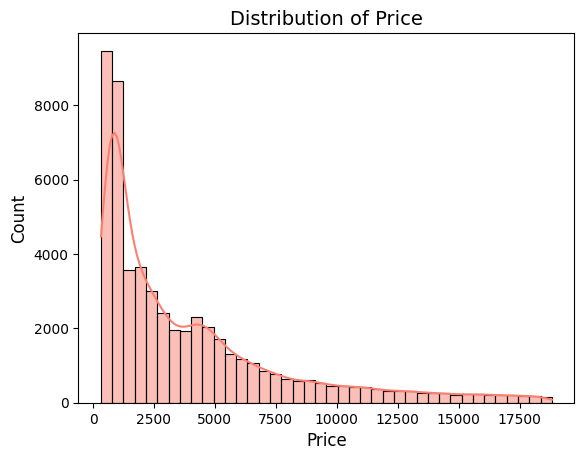

In [20]:
# price 시각화
sns.histplot(price, bins=40, kde=True, color='salmon')
plt.title('Distribution of Price', fontsize=14)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

**• price 데이터에서 표본의 크기를 2, 20, 200으로 설정한 후 표본의 평균과 표준편차 구하기**

In [ ]:
# 표본 크기 리스트
sample_sizes = [2, 20, 200]

for size in sample_sizes:
    sample_means = make_sampling_distribution(price, sample_size=size, num_samples=10000)
    
    # 표본 평균들의 평균과 표준편차 계산
    dist_mean = np.mean(sample_means)
    dist_std = np.std(sample_means)
    
    print(f"[표본 크기 n = {size}]")
    print(f"  - 표본 평균들의 평균: {dist_mean:.2f}")
    print(f"  - 표본 평균들의 표준편차 (표준오차): {dist_std:.2f}") 
    print("-" * 45)

[표본 크기 n = 2]
  - 표본 평균들의 평균: 3895.94
  - 표본 평균들의 표준편차 (표준오차): 2799.77
---------------------------------------------
[표본 크기 n = 20]
  - 표본 평균들의 평균: 3918.93
  - 표본 평균들의 표준편차 (표준오차): 886.71
---------------------------------------------
[표본 크기 n = 200]
  - 표본 평균들의 평균: 3930.49
  - 표본 평균들의 표준편차 (표준오차): 280.01
---------------------------------------------


**• price 데이터에서 표본의 크기를 2, 20, 200으로 설정한 후 표본평균의 분포 시각화하기(히스토그램)**  
✓ 표본평균의 분포 시각화 시 평균과 표준편차를 사용한 정규분포 그래프를 함께 시각화

[표본 크기 n = 2]
 - 표본 평균들의 평균: 3955.69
 - 표본 평균들의 표준편차 (표준오차): 2843.06
---------------------------------------------


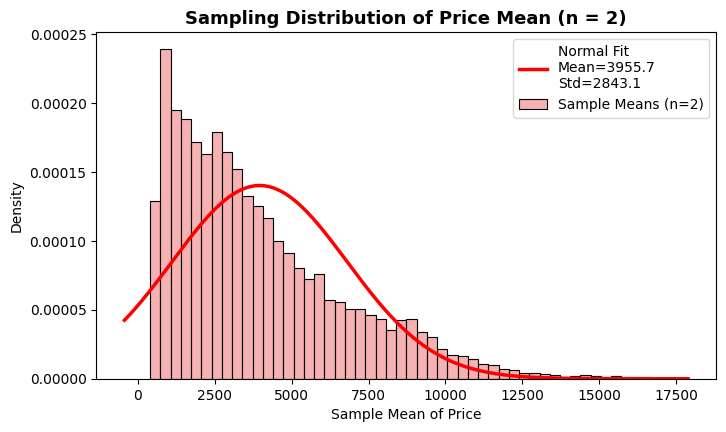

[표본 크기 n = 20]
 - 표본 평균들의 평균: 3932.16
 - 표본 평균들의 표준편차 (표준오차): 877.16
---------------------------------------------


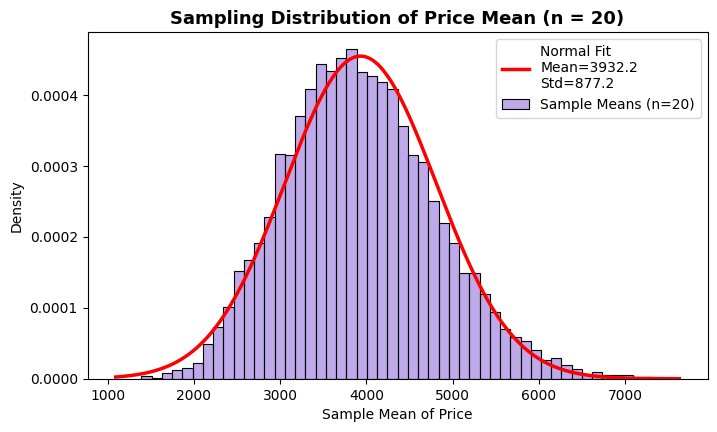

[표본 크기 n = 200]
 - 표본 평균들의 평균: 3932.03
 - 표본 평균들의 표준편차 (표준오차): 285.42
---------------------------------------------


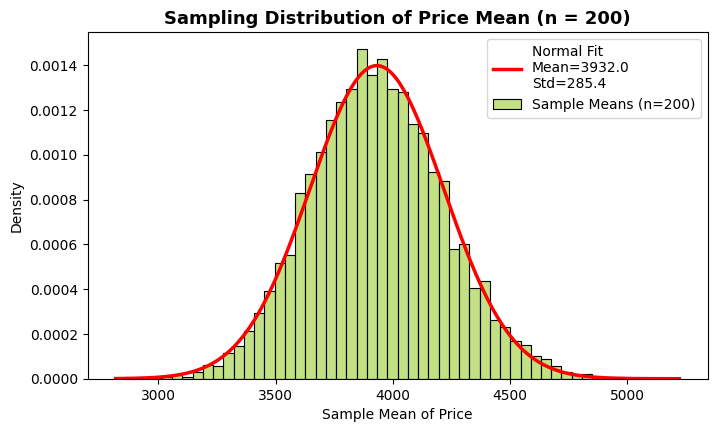

In [22]:
colors = ['lightcoral', 'mediumpurple', 'yellowgreen']

for size, color in zip(sample_sizes, colors):
    # 10,000개의 표본 평균 생성
    sample_means = make_sampling_distribution(price, sample_size=size, num_samples=10000)
    
    # 표본 평균들의 평균과 표준편차 계산
    dist_mean = np.mean(sample_means)
    dist_std = np.std(sample_means)
    
    print(f"[표본 크기 n = {size}]")
    print(f" - 표본 평균들의 평균: {dist_mean:.2f}")
    print(f" - 표본 평균들의 표준편차 (표준오차): {dist_std:.2f}")
    print("-" * 45)
    
    # 시각화
    plt.figure(figsize=(8, 4.5))
    sns.histplot(sample_means, bins=50, stat='density', color=color, alpha=0.6, label=f'Sample Means (n={size})')
    
    # 정규분포 곡선 피팅
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 300)
    plt.plot(x, norm.pdf(x, dist_mean, dist_std), 'r-', linewidth=2.5,
             label=f'Normal Fit\nMean={dist_mean:.1f}\nStd={dist_std:.1f}')
    
    plt.title(f'Sampling Distribution of Price Mean (n = {size})', fontsize=13, fontweight='bold')
    plt.xlabel('Sample Mean of Price')
    plt.ylabel('Density')
    plt.legend()
    plt.show()